In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

df = pd.read_parquet('../data/processed/protein_features_hol.parquet')

CATEGORICALS = ["family", "city", "state", "store_type", "store_nbr", "item_nbr", "class", "cluster"]
for c in CATEGORICALS:
    df[c] = df[c].astype("category")

valid = df[(df["date"] >= "2017-07-15") & (df["date"] < "2017-07-31")].copy()
model = lgb.Booster(model_file='../models/lgbm_holidays.txt')
FEATURES = [c for c in df.columns if c not in ["date", "unit_sales"]]

sample = valid.sample(n=20000, random_state=42)
X = sample[FEATURES]
print(f"Sampled {len(X):,} of {len(valid):,} rows")

Matplotlib is building the font cache; this may take a moment.


Sampled 20,000 of 129,573 rows


In [2]:
# compute TreeSHAP via LightGBM:

shap_raw = model.predict(X, pred_contrib=True)

# Last column is the base value (expected prediction); the rest are per-feature contributions
shap_values = shap_raw[:, :-1]
base_value = shap_raw[0, -1]

print("Shape:", shap_raw.shape, "→", len(FEATURES), "features + 1 base value")
print(f"Base value (log space): {base_value:.4f} → {np.expm1(base_value):.2f} units")

# Verify: base + contributions should equal the model's prediction
check = base_value + shap_values[0].sum()
actual_pred = model.predict(X.iloc[[0]])[0]
print(f"\nReconstruction check: {check:.6f} vs {actual_pred:.6f}")

Shape: (20000, 44) → 43 features + 1 base value
Base value (log space): 1.4380 → 3.21 units

Reconstruction check: 3.368286 vs 3.368286


In [3]:
# global importance by mean absolute SHAP:

shap_df = pd.DataFrame(shap_values, columns=FEATURES)

importance = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    "mean_shap": shap_values.mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

importance["pct"] = (importance["mean_abs_shap"] / importance["mean_abs_shap"].sum() * 100).round(2)

print(importance.head(20).to_string(index=False))

          feature  mean_abs_shap  mean_shap   pct
     roll_mean_14       0.251974   0.044367 20.95
     roll_mean_28       0.210204   0.042129 17.48
      onpromotion       0.128221   0.042687 10.66
      roll_mean_7       0.087235   0.012891  7.25
        dayofweek       0.076605   0.000028  6.37
            lag_1       0.070818  -0.012750  5.89
            lag_7       0.049984  -0.013791  4.16
         item_nbr       0.045353  -0.005188  3.77
  days_since_sale       0.036926   0.007046  3.07
       is_weekend       0.036506   0.015076  3.04
           lag_28       0.031902  -0.013893  2.65
           lag_14       0.030266  -0.009299  2.52
        store_nbr       0.029649  -0.001017  2.47
   promo_count_28       0.017244  -0.008720  1.43
              day       0.016579  -0.015737  1.38
     zero_rate_28       0.016268   0.001623  1.35
      promo_lag_1       0.009509  -0.005254  0.79
       roll_std_7       0.006897   0.002906  0.57
            class       0.006814  -0.001908  0.57


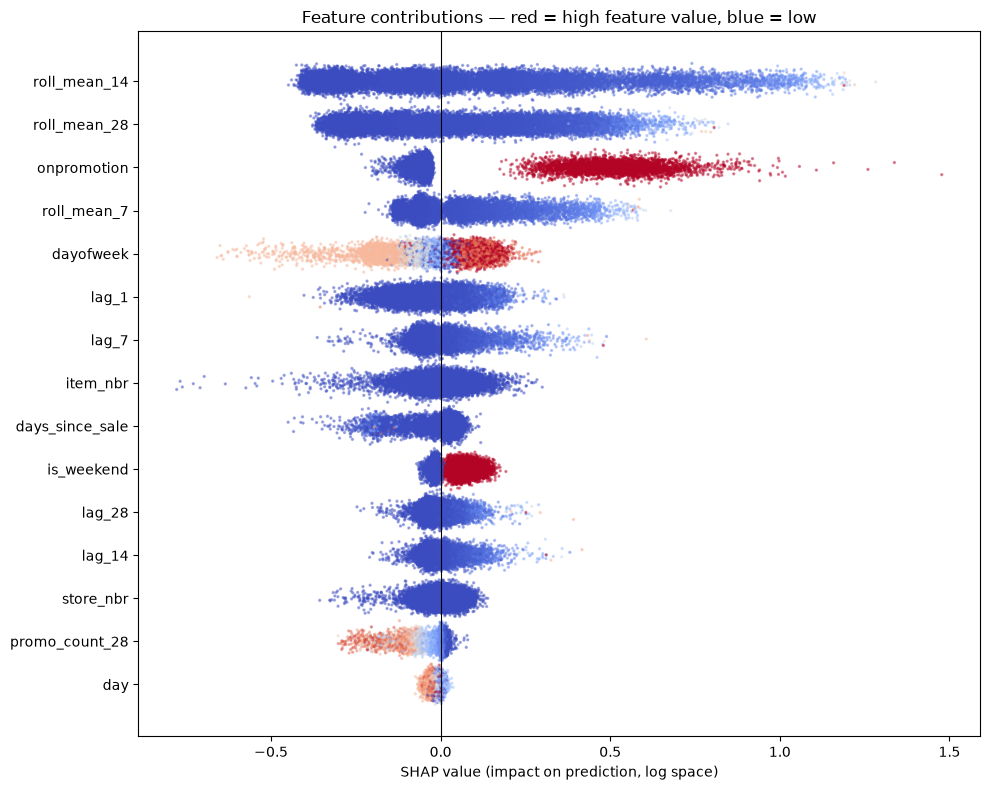

In [5]:
# the beeswarm-equivalent plot:

top_n = 15
top_feats = importance.head(top_n)["feature"].tolist()

fig, ax = plt.subplots(figsize=(10, 8))
for i, feat in enumerate(reversed(top_feats)):
    vals = shap_df[feat].values
    col = X[feat]

    if pd.api.types.is_bool_dtype(col):
        norm = col.values.astype(float)
    elif pd.api.types.is_numeric_dtype(col):
        fv = col.values.astype(float)
        lo, hi = np.nanmin(fv), np.nanmax(fv)
        norm = (fv - lo) / (hi - lo + 1e-9)
    else:
        norm = np.full(len(vals), 0.5)

    jitter = np.random.normal(0, 0.12, len(vals))
    ax.scatter(vals, i + jitter, c=norm, cmap="coolwarm", s=2, alpha=0.4)

ax.set_yticks(range(top_n))
ax.set_yticklabels(list(reversed(top_feats)))
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("SHAP value (impact on prediction, log space)")
ax.set_title("Feature contributions — red = high feature value, blue = low")
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

In [6]:
importance.to_csv('../reports/shap_importance.csv', index=False)
print("Saved.")

Saved.
